# Required Input CSV
This script requires the output CSV from the precipitation script (`site_summary_1km2.csv`). **Make sure this file exists in the expected path before running.**

# Libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr # Using for Spearman Rank Correlation
import scipy.stats as stats

# Spearman Rank Correlation Function
**Purpose**: A function that computes a Spearman rank correlation between groundwater trend and ET/precip ratio  for a given buffer size, both overall and grouped by region.

- Data Validation: Make sure we have correct values, view Minimum and Maximum values, total rows
- Prints overall rho and p-value, followed by per-region rho, p-value, and sample size (n)
- **Output**: Saves results to a CSV in the outputs folder
- Plot a scatterplot colored by region with a linear regression line

### The only changes needed are:
- Uncomment the `# CHANGE HERE` line under the CSV export to save results
- Uncomment the desired buffer size at the bottom of the code chunk

--- Validation: 1km ---
  Rows: 50
  Regions: ['Southern Kansas' 'Western Texas' 'Central Nebraska' 'Arkansas Delta'
 'Western Utah' 'Southern Idaho' 'SoCal_Arizona']
  gw_trend_m_per_yr  -> min: -0.077, max: 2.330, nulls: 0
  et_precip_ratio    -> min: 0.547, max: 6.540, nulls: 0

Spearman Rank for: 1km
Overall: rho = 0.528, p = 0.000

  Arkansas Delta: rho = 0.750, p = 0.052, n = 7
  Central Nebraska: rho = 0.286, p = 0.535, n = 7
  SoCal_Arizona: rho = 0.667, p = 0.071, n = 8
  Southern Idaho: rho = -0.400, p = 0.600, n = 4
  Southern Kansas: rho = 0.830, p = 0.003, n = 10
  Western Texas: rho = 0.850, p = 0.004, n = 9
  Western Utah: rho = 0.200, p = 0.747, n = 5


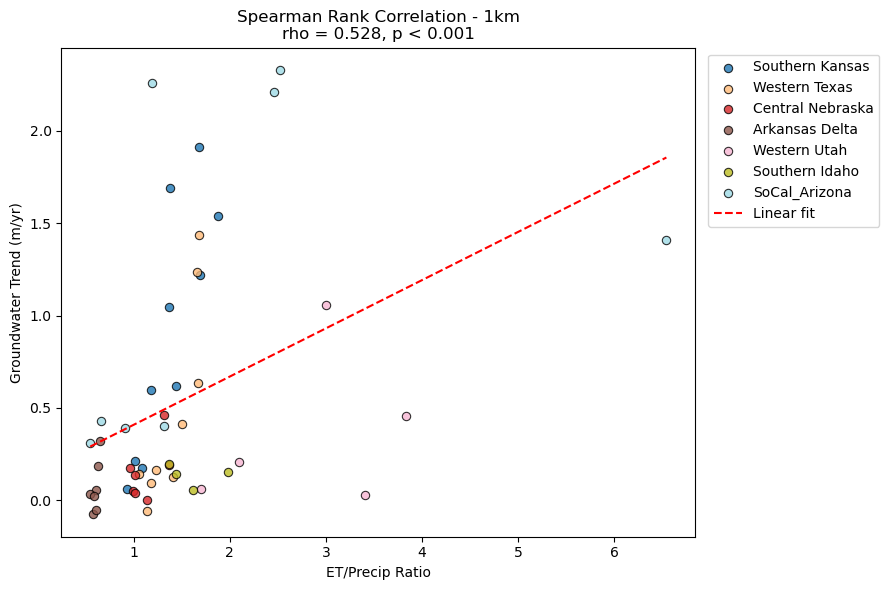

In [ ]:
# Begin Function
def spearman_analysis(csv_path, label=""):
    df = pd.read_csv(csv_path)

    # Data Validation
    print(f"--- Validation: {label} ---")
    print(f"  Rows: {len(df)}")
    print(f"  Regions: {df['region'].unique()}")
    print(f"  gw_trend_m_per_yr  -> min: {df['gw_trend_m_per_yr'].min():.3f}, max: {df['gw_trend_m_per_yr'].max():.3f}, nulls: {df['gw_trend_m_per_yr'].isna().sum()}")
    print(f"  et_precip_ratio    -> min: {df['et_precip_ratio'].min():.3f}, max: {df['et_precip_ratio'].max():.3f}, nulls: {df['et_precip_ratio'].isna().sum()}\n")

    # Create an empty variable to store results
    results = []

    # Run Spearmans
    rho, p_value = spearmanr(df['gw_trend_m_per_yr'], df['et_precip_ratio'])
    results.append({'region': 'ALL', 'rho': rho, 'p_value': p_value, 'n': len(df)})

    print(f"Spearman Rank for: {label}")
    print(f"Overall: rho = {rho:.3f}, p = {p_value:.3f}\n")

    # Grouping by Region to get spearman rank for each region
    for region, group in df.groupby('region'):
        # Must have at least 3 site locations
        if len(group) < 3:
            continue
        # Run Spearmans
        r, p = spearmanr(group['gw_trend_m_per_yr'], group['et_precip_ratio'])
        # Add results into empty variable created above
        results.append({'region': region, 'rho': r, 'p_value': p, 'n': len(group)})
        print(f"  {region}: rho = {r:.3f}, p = {p:.3f}, n = {len(group)}")

    # Export a Spearman Rank Correlation CSV
    # CHANGE HERE: Add desired output location
    # pd.DataFrame(results).to_csv(f"/capstone/aridgw/outputs/1km/site_summary_spearman_{label}.csv", index=False)

    # Scatter Plot
    fig, ax = plt.subplots(figsize=(9, 6))
    regions = df['region'].unique()
    colors = plt.cm.tab20(np.linspace(0, 1, len(regions)))

    for region, color in zip(regions, colors):
        subset = df[df['region'] == region]
        ax.scatter(subset['et_precip_ratio'], subset['gw_trend_m_per_yr'],
                   label=region, color=color, alpha=0.80,
                   edgecolors="black", linewidths=0.8)

    m, b, *_ = stats.linregress(df['et_precip_ratio'], df['gw_trend_m_per_yr'])
    x = np.linspace(df['et_precip_ratio'].min(), df['et_precip_ratio'].max(), 100)
    ax.plot(x, m * x + b, 'r--', label='Linear fit')

    ax.set_xlabel('ET/Precip Ratio')
    ax.set_ylabel('Groundwater Trend (m/yr)')
    ax.set_title(f"Spearman Rank Correlation - {label}\nrho = {rho:.3f}, p < 0.001")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# CHANGE HERE: Run for desired buffer size (uncomment one):
spearman_analysis("/capstone/aridgw/outputs/1km/site_summary_1km2.csv", label="1km")
# spearman_analysis("/capstone/aridgw/outputs/5km/site_summary_2km.csv", label="2km")
# spearman_analysis("/capstone/aridgw/outputs/10km/site_summary_4km.csv", label="4km")
# spearman_analysis("/capstone/aridgw/outputs/25km/site_summary_10km.csv", label="10km")